{'horsepower_model': 20.829300555790315}

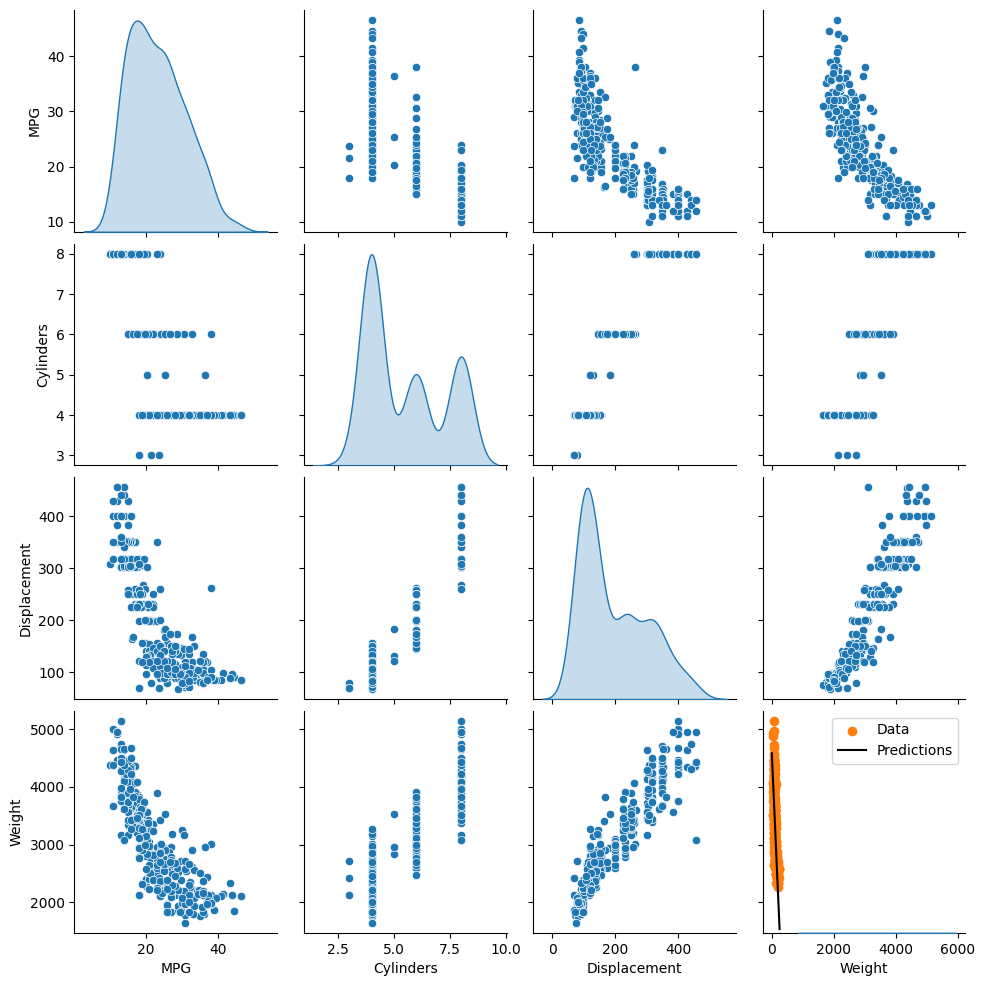

In [1]:
# %%
import pandas as pd

dataset = pd.read_csv("../data/auto_mpg.csv")
dataset.head()





# %%
# Tamaño del dataset

dataset.shape


# %%
# Búsqueda de valores nulos

dataset.isna().sum()

# por ejemnplo

# %%
# Remoción de valores nulos

dataset = dataset.dropna()
dataset.isna().sum()


# %%
# Columna Origin
# Nota:  1) USA
#        2) Europe
#        3) Japan

dataset.Origin.value_counts()



# %%Profe guapo

# Convierte la columna a categorias.
# Nota. Realmente no se debería hacer asi para aplicaciones
# en productivo

dataset["Origin"] = dataset["Origin"].map(
    {   
        1: "USA", 
        2: "Europe", 
        3: "Japan",
    },
)





# %%
# Genera variables dummy para indicar la procedencia (Pésima solución)

dataset = pd.get_dummies(dataset, columns=["Origin"], prefix="", prefix_sep="")
dataset.head()






# Note que aca no se usa train_test_split

train_dataset = dataset.sample(frac=0.8, random_state=0)
test_dataset = dataset.drop(train_dataset.index)





# Las millas por galon (MPG) son función de las demas variables.

import seaborn as sns

sns.pairplot(
    train_dataset[["MPG", "Cylinders", "Displacement", "Weight"]], diag_kind="kde"
)



# %%

# Cálculo de algunas estadísticas generales

train_dataset.describe().transpose()







# %%
# Particionamiento de los datos en features y labels

train_features = train_dataset.copy()
train_labels = train_features.pop("MPG")

test_features = test_dataset.copy()
test_labels = test_features.pop("MPG")



# %%
# Estandarización de los datos (normalización)

train_dataset.describe().transpose()[["mean", "std"]]




# Efecto del StandardScaler

from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

pd.DataFrame(
    data=scaler.fit_transform(train_dataset),
    columns=train_dataset.columns,
).describe().transpose()[["mean", "std"]]






  # %%
  # Regresión lineal con una sola variable (Horsepower)

horsepower_scaler = StandardScaler()

train_horsepower = train_features[["Horsepower"]]
test_horsepower = test_features[["Horsepower"]]

horsepower_scaler.fit(train_horsepower)

standarized_train_horsepower = horsepower_scaler.transform(train_horsepower)
standarized_test_horsepower = horsepower_scaler.transform(test_horsepower)







# %%
# Modelo de regresión lineal

from sklearn.linear_model import LinearRegression

horsepower_model = LinearRegression()
horsepower_model.fit(standarized_train_horsepower, train_labels)






# %%

# Intercepto
horsepower_model.intercept_





# Coeficientes
horsepower_model.coef_





# %%
import numpy as np

x = pd.DataFrame({"Horsepower": np.linspace(0, 250, 251)})
x.head()




# %%
# Predicción

scaled_x = horsepower_scaler.transform(x)
y = horsepower_model.predict(scaled_x)
y[:5]





# %%
import matplotlib.pyplot as plt


def plot_horsepower(x, y):
    plt.scatter(train_features["Horsepower"], train_labels, label="Data")
    plt.plot(x, y, color="k", label="Predictions")
    plt.xlabel("Horsepower")
    plt.ylabel("MPG")
    plt.legend()
    
    
    
    
    

plot_horsepower(x, y)




# Evaluación

from sklearn.metrics import mean_squared_error

test_results = {}

y_pred = horsepower_model.predict(standarized_test_horsepower)

test_results["horsepower_model"] = mean_squared_error(
    y_true=test_labels,
    y_pred=y_pred,
)

test_results




